# ARTEMIS plasma-region classification

This notebook shows how to use the ARTEMIS CMMAE package to get classifications for ARTEMIS data. Pyspedas is a required dependency bundled with the package, so you can just specify a probe (e.g. 'thb' or 'thc') and a time interval (e.g. ["2012-10-23", "2012-11-04"]) and it will handle the downloading, preprocessing, and model inference. Note that this model was trained on and built for ESA Full data products (often either 2-mins or 8-mins resolution) and *not* the ESA reduced data (spin resolution, or about ~4s).

The figure at the bottom shows an ion energy spectrogram, the GSE magnetic field, ion density
and temperature (although temperature is not required for model inference), and two region strips -- the full per-sample `raw`
classification and a persistence strip (`1h` by default) that keeps only regions
held continuously for at least that long -- beside the GSE X-Y orbit with Shue
magnetopause and Chao bow-shock curves.

Everything (pyspedas, matplotlib, etc.) installs with the package:

```
pip install artemis-cmmae
```

## Pyspedas ARTEMIS download

This ~12-day pass downloads roughly **1 GB** of ARTEMIS CDFs (ESA + FGM + state). pyspedas caches them under the folder
set by the env var `SPEDAS_DATA_DIR` (you can change the path of 'data_dir' yourself if you want them saved at a different location on your machine).

In [1]:
import os
from pathlib import Path

# set os var for pyspedas to specify save data location
data_dir = Path.cwd().resolve() / "artemis_cmmae_data"
os.environ["SPEDAS_DATA_DIR"] = str(data_dir)

# hide warnings and logging
import warnings, logging
warnings.filterwarnings("ignore")            # sklearn version warning
logging.getLogger().setLevel(logging.ERROR)  # pyspedas download logs

from artemis_cmmae import PlasmaClassifier
from artemis_cmmae.plotting import plot_classification_timeseries

In [2]:
clf = PlasmaClassifier(
        # alpha=1 is the definitive model; alpha=5,10 are smaller (less accurate)
        # alpha=1
)

PlasmaClassifier initialized on cuda
  Alpha (map size penalty): 1
  MMAE latent_dim: 6
  SOM shape: (16, 20) (320 nodes)


In [3]:
%%capture

# download data for probe and time interval, preprocess data for model, then use classifier
probe = 'thb'
trange = ["2012-10-23", "2012-11-04"]
labeled_df = clf.predict_from_pyspedas(
    probe=probe,
    trange=trange,
    drop_wake=False,        # if True, drops s/c potential <= 1 V (+ 1 before/after adjacent-in-time steps)
    return_features=True,
    verbose=False,
)

# mask out lunar wake data
labeled_df_no_wake = labeled_df[ ~labeled_df['in_wake'] ]

In [4]:
list(labeled_df_no_wake)

['region_id',
 'region_name',
 'in_wake',
 'X_GSE',
 'Y_GSE',
 'Z_GSE',
 'X_GSM',
 'Y_GSM',
 'Z_GSM',
 'C0',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'C15',
 'C16',
 'C17',
 'C18',
 'C19',
 'C20',
 'C21',
 'C22',
 'C23',
 'C24',
 'C25',
 'C26',
 'C27',
 'C28',
 'C29',
 'C30',
 'n',
 'SCPot',
 'T',
 'BX_GSE',
 'BY_GSE',
 'BZ_GSE',
 'BX_GSM',
 'BY_GSM',
 'BZ_GSM']

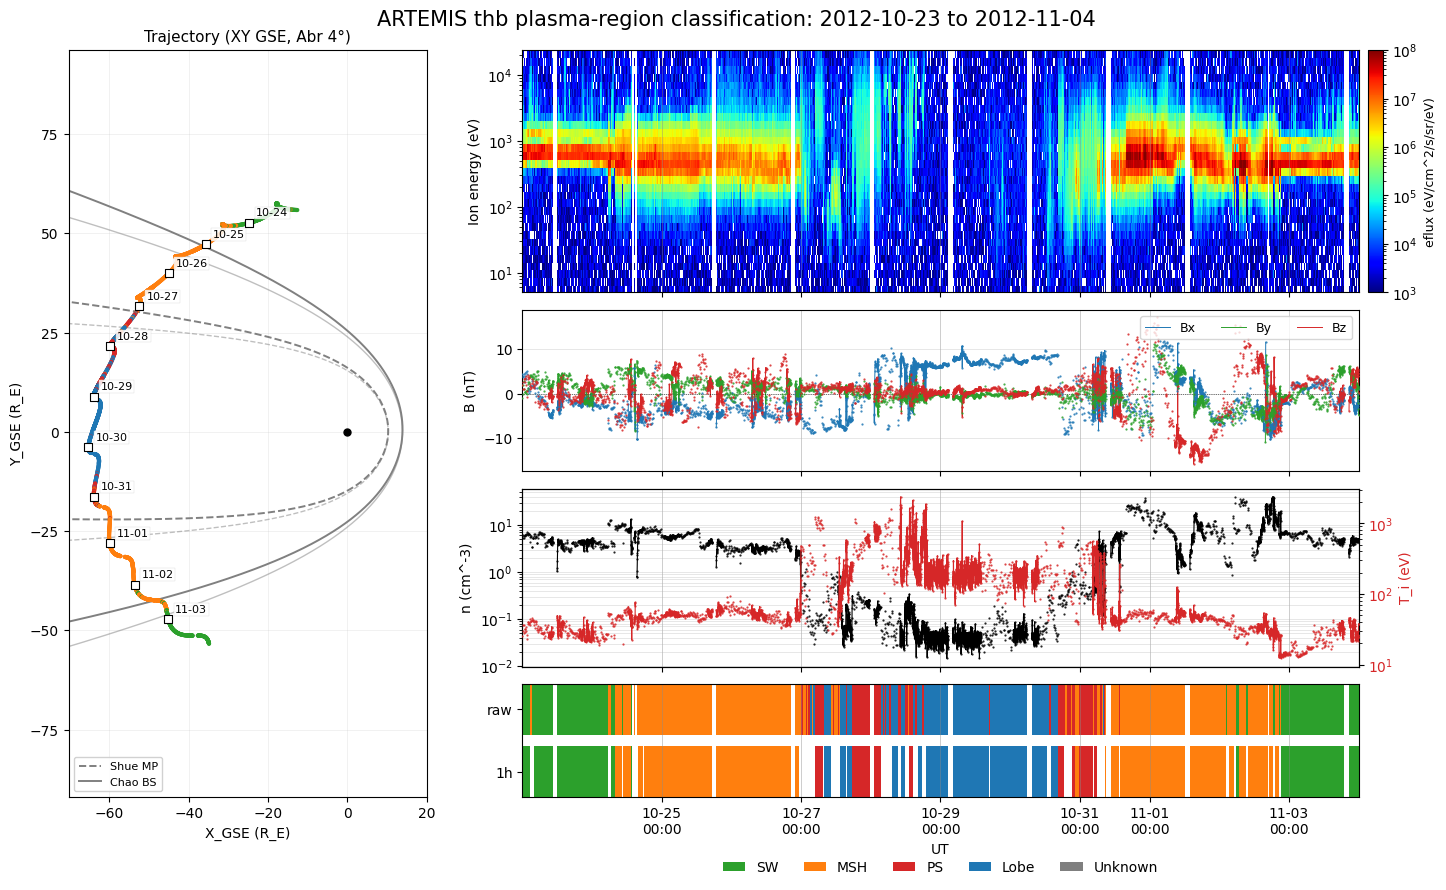

In [5]:
# Render figure. `min_duration` sets the persistence strip's dwell threshold
# (and its y-axis label); default is "1h" -- try "2h", "30min", etc.
fig = plot_classification_timeseries(
    labeled_df_no_wake,
    min_duration="1h",
    title=f"ARTEMIS {probe} plasma-region classification: {trange[0]} to {trange[1]}",
)

## Consecutive-region ("persistence") series

The figure's persistence strip is just the `region_timeline` filter, which you
can also call directly to get the series yourself: it keeps only samples whose
region was held continuously for at least `min_duration` -- a strict subset of
the labels, with flickering / short-lived classifications dropped.

In [6]:
from artemis_cmmae import region_timeline

# Same filter the figure's persistence strip uses; anything not held in one
# region for >= min_duration is dropped (use the same value as the plot above).
persistent = region_timeline(labeled_df_no_wake, min_duration="1h")
print(f"{len(labeled_df_no_wake)} labelled samples -> {len(persistent)} kept (>=1h continuous)")
persistent["region_name"].value_counts()

3963 labelled samples -> 3463 kept (>=1h continuous)


region_name
Magnetosheath    1516
Lobe              970
Solar Wind        700
Plasma Sheet      277
Name: count, dtype: int64